# The projected list

The adopted methodology, run against the cycle that closed 2026-06-30, and
what it does that a count-based ranking would not.


In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd

import fasttrack as ft

pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 80)


In [2]:
table = ft.rank_districts()
table.head(15)


,census_units_2020,net_new_units,housing_units,affordable_units,buildings,rate,rate_pct,rate_rank,count_rank,on_fast_track,on_count_list
district,,,,,,,,,,,
MN-05,42323,509,42832,0,0,0.000000,0.000000,1,1,True,True
BK-10,55768,56,55824,0,0,0.000000,0.000000,2,2,True,True
SI-03,62782,436,63218,4,1,0.000063,0.006327,3,3,True,True
QN-13,66259,114,66373,9,5,0.000136,0.013560,4,5,True,True
QN-10,43252,41,43293,7,3,0.000162,0.016169,5,4,True,True
SI-02,51599,206,51805,23,15,0.000444,0.044397,6,6,True,True
MN-07,126397,284,126681,68,1,0.000537,0.053678,7,9,True,True
BK-18,72361,37,72398,49,8,0.000677,0.067681,8,7,True,True
MN-08,138922,487,139409,150,6,0.001076,0.107597,9,16,True,False


## Rate versus count

The rule ranks units built over total housing stock. Most coverage assumes a
count. These are the districts where the two disagree.


In [3]:
swapped = table[table["on_fast_track"] != table["on_count_list"]]
swapped[
    ["affordable_units", "housing_units", "rate_pct", "rate_rank", "count_rank", "on_fast_track"]
]


,affordable_units,housing_units,rate_pct,rate_rank,count_rank,on_fast_track
district,,,,,,
MN-08,150,139409,0.107597,9,16,True
QN-09,106,50995,0.207864,15,12,False


A district is pulled onto the list by having a large denominator, not a small
numerator - so the displaced districts built *fewer* units than the ones that
replaced them.


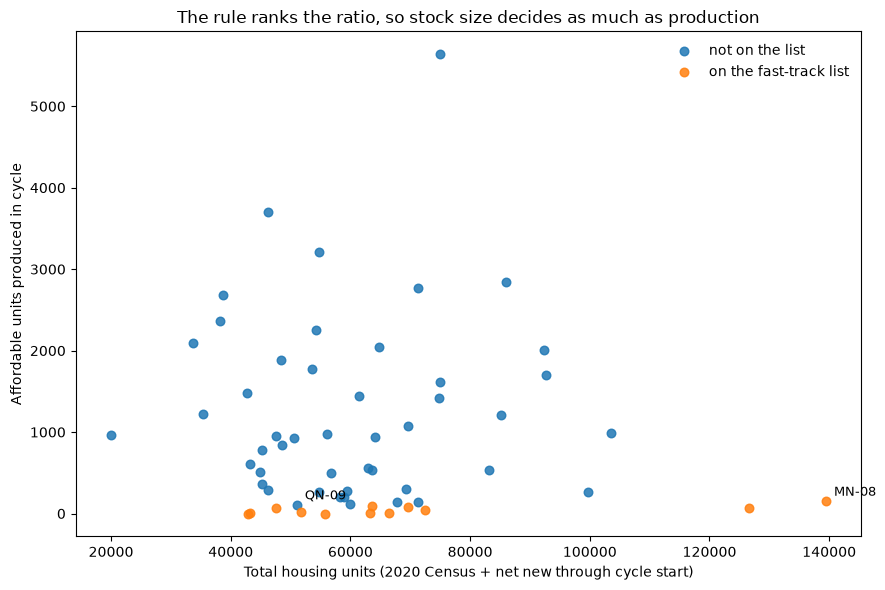

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6))
for on, group in table.groupby("on_fast_track"):
    ax.scatter(
        group["housing_units"],
        group["affordable_units"],
        s=38,
        alpha=0.85,
        label="on the fast-track list" if on else "not on the list",
    )
for district in swapped.index:
    row = table.loc[district]
    ax.annotate(district, (row["housing_units"], row["affordable_units"]),
                textcoords="offset points", xytext=(6, 4), fontsize=9)

ax.set_xlabel("Total housing units (2020 Census + net new through cycle start)")
ax.set_ylabel("Affordable units produced in cycle")
ax.set_title("The rule ranks the ratio, so stock size decides as much as production")
ax.legend(frameon=False)
fig.tight_layout()


## How stable is the list?

Each variant is one defensible alternative reading of a place where the public
data does not line up exactly with the rule's language.


In [5]:
import rank

results = rank.run_sensitivity()



On the list under every variant:
  BK-12 (Brooklyn)
  BK-18 (Brooklyn)
  QN-05 (Queens)
  QN-10 (Queens)
  QN-11 (Queens)
  QN-13 (Queens)
  SI-02 (Staten Island)

Contested - on the list under some readings and not others:
  BK-10 (Brooklyn)       on under: base, no_permit_condition, cycle_through_hpd_data
  BK-11 (Brooklyn)       on under: include_preservation
  BX-10 (Bronx)          on under: include_preservation
  MN-05 (Manhattan)      on under: base, no_permit_condition, cycle_through_hpd_data
  MN-06 (Manhattan)      on under: include_preservation
  MN-07 (Manhattan)      on under: base, no_permit_condition, cycle_through_hpd_data
  MN-08 (Manhattan)      on under: base, no_permit_condition, cycle_through_hpd_data
  QN-03 (Queens)         on under: include_preservation
  QN-09 (Queens)         on under: include_preservation
  SI-03 (Staten Island)  on under: base, no_permit_condition, cycle_through_hpd_data

Rate rank by variant (districts ranked 1-18 in the base run):
       

## Around the cutoff

The districts close enough to twelfth that a data gap decides them.


In [6]:
ft.ties_near_cutoff(table)


,census_units_2020,net_new_units,housing_units,affordable_units,buildings,rate,rate_pct,rate_rank,count_rank,on_fast_track,on_count_list,pct_points_from_cutoff
district,,,,,,,,,,,,
MN-08,138922,487,139409,150,6,0.001076,0.107597,9,16,True,False,-0.040327
QN-05,69416,260,69676,76,5,0.001091,0.109076,10,10,True,True,-0.038848
QN-11,47357,124,47481,66,6,0.001390,0.139003,11,8,True,True,-0.008921
BK-12,62782,764,63546,94,14,0.001479,0.147924,12,11,True,True,0.000000
BK-11,71074,166,71240,138,5,0.001937,0.193711,13,14,False,False,0.045787
QN-08,59385,520,59905,123,8,0.002053,0.205325,14,13,False,False,0.057401
QN-09,50877,118,50995,106,12,0.002079,0.207864,15,12,False,True,0.059939
